# Feasible CaSSLe PoC

Safe experiment interface for CIFAR-100 smoke and pilot runs. Expensive training is disabled by default.

In [1]:
from pathlib import Path
import csv, json, os, subprocess, sys

RUN_TRAINING = False
CONFIG_PATH = 'config/feasible_cassle_cifar100_smoke.yaml'
RESULT_DIR = 'outputs'

print('cwd:', Path.cwd())
print('python:', sys.version.split()[0])
print('git:', subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], text=True).strip())

cwd: /home/jovyan/TML/Project/cassle
python: 3.11.6
git: b5b0929


## Configuration Loading And Device

In [2]:
from src.config import load_config
from src.data import cifar_task_order
from src.utils import choose_device

cfg = load_config(CONFIG_PATH)
device = choose_device(cfg['experiment'].get('device', 'auto'))
tasks = cifar_task_order(cfg['experiment']['seed'])
print('config:', cfg['experiment']['name'])
print('device:', device)
print('task sizes:', [len(t) for t in tasks])

config: feasible_cassle_cifar100_smoke
device: cpu
task sizes: [20, 20, 20, 20, 20]


## Runtime Diagnostics

In [3]:
from src.temporal_losses import derangement

perm = derangement(16)
assert not (perm == __import__('torch').arange(16)).any()
print('derangement ok:', perm.tolist())

try:
    import pytorch_lightning
    print('pytorch_lightning available')
except ModuleNotFoundError:
    print('pytorch_lightning missing: training requires the repository dependencies from README.md')

derangement ok: [8, 6, 14, 9, 12, 0, 15, 11, 2, 4, 5, 10, 13, 1, 7, 3]
pytorch_lightning available


## CIFAR-100 Task Split

In [4]:
for i, task in enumerate(tasks):
    print(f'task {i}:', task.tolist())

task 0: [11, 22, 39, 23, 42, 30, 78, 81, 64, 20, 29, 79, 15, 69, 86, 63, 55, 53, 73, 68]
task 1: [89, 67, 58, 97, 96, 92, 37, 14, 75, 51, 54, 7, 3, 6, 50, 40, 45, 4, 83, 98]
task 2: [27, 12, 8, 99, 60, 87, 28, 5, 84, 34, 82, 16, 72, 49, 59, 31, 71, 35, 66, 76]
task 3: [61, 17, 36, 62, 13, 2, 38, 94, 80, 19, 25, 18, 0, 1, 46, 74, 85, 91, 52, 77]
task 4: [21, 33, 32, 88, 93, 70, 44, 47, 26, 57, 90, 95, 48, 65, 43, 10, 9, 56, 24, 41]


## Train Or Reuse Shared Task-1 Checkpoint

In [5]:
if RUN_TRAINING:
    from src.experiments import prepare_run
    from src.trainer import train_task1
    cfg, device, run_dir, tasks = prepare_run(CONFIG_PATH)
    ckpt = train_task1(cfg, run_dir, device, tasks)
    RESULT_DIR = str(run_dir)
    print('task1 checkpoint:', ckpt)
else:
    print('skipped; set RUN_TRAINING = True to run')

skipped; set RUN_TRAINING = True to run


## Smoke Experiment

In [6]:
if RUN_TRAINING:
    from src.experiments import run_smoke
    result = run_smoke(CONFIG_PATH)
    RESULT_DIR = result['run_dir']
    print(json.dumps(result, indent=2)[:2000])
else:
    print('skipped; command: python -m src.experiments --config', CONFIG_PATH, '--run smoke')

skipped; command: python -m src.experiments --config config/feasible_cassle_cifar100_smoke.yaml --run smoke


## Inspect One Constrained Update

In [7]:
if RUN_TRAINING:
    from src.experiments import inspect_one_update
    inspection = inspect_one_update(CONFIG_PATH)
    print(json.dumps(inspection, indent=2))
else:
    print('skipped; command: python -m src.experiments --config', CONFIG_PATH, '--run inspect')

skipped; command: python -m src.experiments --config config/feasible_cassle_cifar100_smoke.yaml --run inspect


## Selected Pilot Baselines

In [8]:
PILOT_CONFIG = 'config/feasible_cassle_cifar100_pilot.yaml'
PILOT_METHODS = ['offline_ssl', 'finetune', 'standard_cassle', 'crossfit_cassle', 'feasible_cassle']
if RUN_TRAINING:
    from src.experiments import run_pilot_selection
    result = run_pilot_selection(PILOT_CONFIG, methods=PILOT_METHODS)
    RESULT_DIR = result['run_dir']
    print(RESULT_DIR)
else:
    print('skipped; command: python -m src.experiments --config', PILOT_CONFIG, '--run pilot --methods', ' '.join(PILOT_METHODS))

skipped; command: python -m src.experiments --config config/feasible_cassle_cifar100_pilot.yaml --run pilot --methods finetune standard_cassle crossfit_cassle feasible_cassle


## Load Result Files Without Retraining

In [9]:
def read_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

if RESULT_DIR:
    root = Path(RESULT_DIR)
    eval_logs = {p.parent.name: read_csv(p) for p in root.glob('*/eval_log.csv')}
    train_logs = {p.parent.name: read_csv(p) for p in root.glob('*/train_log.csv')}
    print('loaded methods:', sorted(eval_logs))
else:
    print('set RESULT_DIR to an existing run directory to load results')

loaded methods: []


## Plots And Comparison Table

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


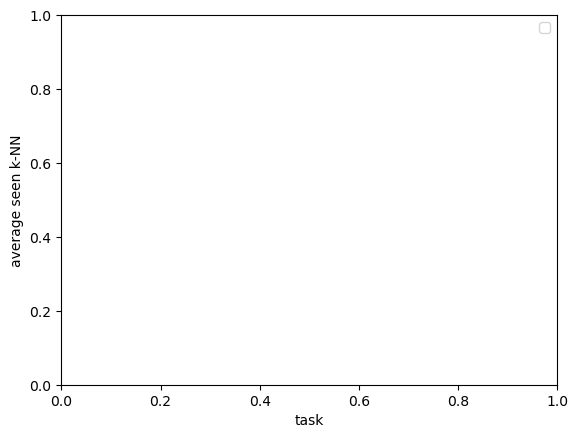

In [10]:
if RESULT_DIR:
    import matplotlib.pyplot as plt
    for method, rows in eval_logs.items():
        xs = [int(r['task']) for r in rows]
        ys = [float(r['avg_seen_knn']) for r in rows]
        plt.plot(xs, ys, marker='o', label=method)
    plt.xlabel('task')
    plt.ylabel('average seen k-NN')
    plt.legend()
    plt.show()
else:
    print('no result directory loaded')

## Go/No-Go Assessment

In [ ]:
if RESULT_DIR:
    print('Assess: current-task accuracy, tuned gamma comparison, forgetting <= 1-2 points, active rate neither 0 nor 100%, conflict frequency, modest correction ratio, shared task-1 checkpoint.')
else:
    print('No assessment without completed pilot results. Smoke runs do not validate the research hypothesis.')